# Imports & Helper Functions

In [1]:
from ast import Param

from pyomo.environ import *
from pyomo.opt import SolverStatus, TerminationCondition
from pyomo.core import ConcreteModel
from pyomo.common.config import PositiveInt

import tsplib95

import os
import math
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import networkx as nx
import plotly.express as px
import plotly.graph_objects as go

In [2]:
# Others notebooks

import import_ipynb
import data_model

In [3]:
# data_model.df

In [4]:
os.environ["NEOS_EMAIL"] = "antonsivko480@gmail.com"

## Plot Function

In [5]:
def plot_tsp_tour(coords, tour, title=None, show_positions=True):
    """
    coords: dict {node: (x, y)}
    tour: список вершин у порядку обходу, наприклад [1, 23, 38, ..., 1]
          якщо останній елемент не дорівнює першому, ми автоматично замкнемо тур
    show_positions: якщо True — підписуємо вершини як "node (step)"
    """

    if tour[0] != tour[-1]:
        tour = list(tour) + [tour[0]]

    start = tour[0]

    position_in_tour = {
        node: idx for idx, node in enumerate(tour[:-1])
    }

    if not isinstance(coords, dict):
        coords = {i: (coords[i][0], coords[i][1]) for i in range(len(coords))}

    plt.figure(figsize=(10, 10))

    for k in range(len(tour) - 1):
        i = tour[k]
        j = tour[k+1]
        x_i, y_i = coords[i]
        x_j, y_j = coords[j]

        dx = x_j - x_i
        dy = y_j - y_i

        plt.arrow(x_i, y_i, dx, dy, length_includes_head=True, head_width=1, head_length=1.75, linewidth=1.0, alpha=0.8, zorder=1)

        # plt.plot([x_i, x_j], [y_i, y_j], color="gray", linewidth=1, zorder=1)

    xs = [coords[i][0] for i in coords]
    ys = [coords[i][1] for i in coords]
    plt.scatter(xs, ys, s=30, color="blue", zorder=2, label="Other Nodes")

    x_s, y_s = coords[start]
    plt.scatter([x_s], [y_s], s=120, color="red", edgecolors="black", zorder=3, label="Start Node")

    for node, (x, y) in coords.items():
        if show_positions and node in position_in_tour:
            step = position_in_tour[node]
            text = f"{node} ({step})"
        else:
            text = str(node)
        plt.text(x, y, text, fontsize=10, ha="right", va="bottom")

    plt.title(title if title else "TSP Tour")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.gca().set_aspect("equal", adjustable="box")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

## Euclidean coordinate converter

In [6]:
def geo_to_euclid(
    lat_deg, lon_deg, # λ and φ
    lat0_deg, lon0_deg, # λ0 and φ0
    R=6371.0, # in km
    base_lat_deg=None # φ1, default = φ0
):
    """
    Перехід від геодезичних координат (широта, довгота в градусах)
    до евклідових (x, y) за формулами зі слайду:

        x = R (λ - λ0) cos(φ1)
        y = R (φ - φ0)

    Повертає (x, y) в тих же одиницях, що й R (метри або кілометри).
    """

    if base_lat_deg is None:
        base_lat_deg = lat0_deg

    # degrees to radians
    lat = math.radians(lat_deg)
    lon = math.radians(lon_deg)
    lat0 = math.radians(lat0_deg)
    lon0 = math.radians(lon0_deg)
    base_lat = math.radians(base_lat_deg)

    # formulas
    x = R * (lon - lon0) * math.cos(base_lat) # R(λ - λ0)cos(φ1)
    y = R * (lat - lat0) # R(φ - φ0)

    return x, y


In [7]:
def geo_list_to_euclid(lat_list, lon_list, R=6371.0):
    """
    Приймає списки широт і довгот (у градусах) однакової довжини.
    Повертає два списки xcoord_list, ycoord_list у тих же одиницях, що й R.
    За нульову точку (0,0) беремо першу вершину.
    """
    assert len(lat_list) == len(lon_list), "lat_list і lon_list мають бути однакової довжини"

    # беремо першу точку як (lat0, lon0) і базову широту φ1 = lat0
    lat0_deg = lat_list[0]
    lon0_deg = lon_list[0]

    xcoord_list = []
    ycoord_list = []

    for lat_deg, lon_deg in zip(lat_list, lon_list):
        x, y = geo_to_euclid(
            lat_deg, lon_deg,
            lat0_deg=lat0_deg,
            lon0_deg=lon0_deg,
            R=R,
            base_lat_deg=lat0_deg # φ1 = φ0
        )
        xcoord_list.append(x)
        ycoord_list.append(y)

    return xcoord_list, ycoord_list


## Geo Coords Loader

In [27]:
def load_geo_dataframe(df, id_col="id", lat_col="lat", lon_col="lon", R=6371.0):
    """
    Завантажує координати з DataFrame з геодезичними координатами (lat/lon),
    переводить їх у декартову систему (x, y) і повертає
    n, x_data, y_data у форматі {node_id: value}, як у TSPLIB-лоадері.

    id_col - колонка з ідентифікатором вершини
    lat_col, lon_col – назви колонок у df з широтою і довготою (у градусах).
    R – радіус Землі (6371.0 – в км; хочеш метри – постав 6371000.0).
    """

    ids = df[id_col].tolist()
    lat_list = df[lat_col].tolist()
    lon_list = df[lon_col].tolist()

    assert len(ids) == len(lat_list) == len(lon_list), "id, lat, lon мають однакову довжину"

    n = len(ids)

    lat0_deg = lat_list[0]
    lon0_deg = lon_list[0]

    x_data = {}
    y_data = {}

    for node_id, lat_deg, lon_deg in zip(ids, lat_list, lon_list):
        x, y = geo_to_euclid(
            lat_deg=lat_deg,
            lon_deg=lon_deg,
            lat0_deg=lat0_deg,
            lon0_deg=lon0_deg,
            R=R,
            base_lat_deg=lat0_deg
        )
        x_data[node_id] = x
        y_data[node_id] = y

    return n, x_data, y_data


In [9]:
# xcoord_list, ycoord_list = geo_list_to_euclid(data_model.lat_list, data_model.lon_list)
#
# xcoord_list, ycoord_list

## Check solver availability

In [10]:

# solver = SolverFactory(
#     "cbc",
#     executable=r"C:\Users\Antonio\Desktop\New folder\bin\cbc.exe"
# )
# print("Is solver available? ->", solver.available())
# print("Is solver executable? ->", solver.executable())


# Base Paramethers & Data

In [11]:
# data = tsplib95.load("TSPLib-data/st70.tsp")
#
# data.node_coords

In [12]:
def load_tsplib_data(filename):
    """
    Завантажує координати та розмірність із файлу .tsp
    """
    problem = tsplib95.load(filename)

    n = problem.dimension

    node_coords = problem.node_coords

    x_data = {}
    y_data = {}

    for node_id, coords in node_coords.items():
        x_data[node_id] = coords[0]
        y_data[node_id] = coords[1]

    return n, x_data, y_data


In [13]:
# tsp_filename = "TSPLib-data/st70.tsp"
tsp_filename = "TSPLib-data/eil76.tsp"
# tsp_filename = "TSPLib-data/kroA100.tsp"
# tsp_filename = "TSPLib-data/kroE100.tsp"
# tsp_filename = "TSPLib-data/eil101.tsp"

## Base Params

In [28]:
USE_TSPLIB = False

if USE_TSPLIB:

    try:
        n_value, xcoord_data, ycoord_data = load_tsplib_data(tsp_filename)
        print(f"Successfully uploaded {tsp_filename}. Number of vertices: {n_value}")
    except FileNotFoundError:
        print(f"File {tsp_filename} not found! Check the path.")
        exit()

else:
    n_value, xcoord_data, ycoord_data = load_geo_dataframe(
        data_model.df,
        lat_col="lat",
        lon_col="lon",
        R=6371.0
    )
    print(f"Loaded {n_value} points from DataFrame (lat/lon → Euclidean)")

s_value = 1
k_value = 5

if k_value > n_value:
    print(f"Adjustment k: {k_value} -> {n_value}")
    k_value = n_value

Loaded 10 points from DataFrame (lat/lon → Euclidean)


In [15]:
# n_value = 100
#
# xcoord_list = [
#     86, 19, 8, 40, 36, 33, 22, 18, 91, 74,
#     16, 80, 59, 9, 8, 16, 32, 34, 69, 82,
#     8, 76, 30, 96, 88, 94, 74, 58, 33, 62,
#     80, 40, 5, 25, 94, 59, 48, 40, 24, 32,
#     48, 18, 16, 53, 17, 50, 49, 82, 38, 10,
#     98, 63, 73, 20, 53, 15, 75, 42, 85, 84,
#     51, 78, 29, 95, 13, 10, 89, 34, 42, 15,
#     34, 17, 53, 40, 63, 86, 51, 25, 52, 50,
#     31, 90, 39, 94, 92, 87, 14, 82, 86, 26,
#     73, 98, 36, 25, 64, 53, 39, 86, 93, 76,
# ]
#
# ycoord_list = [
#     29, 88, 42, 99, 100, 8, 30, 5, 41, 52,
#     35, 9, 28, 73, 92, 41, 28, 84, 64, 51,
#     83, 59, 19, 34, 18, 32, 96, 72, 69, 34,
#     96, 75, 55, 75, 52, 47, 29, 18, 66, 64,
#     12, 97, 7, 15, 20, 81, 21, 88, 55, 77,
#     9, 50, 49, 77, 60, 68, 33, 71, 2, 88,
#     93, 15, 88, 69, 97, 35, 99, 83, 44, 15,
#     38, 56, 21, 59, 1, 93, 93, 34, 65, 98,
#     23, 65, 14, 81, 39, 82, 65, 78, 26, 20,
#     48, 98, 21, 70, 100, 68, 1, 77, 42, 63,
# ]
#
# xcoord_data = {i + 1: xcoord_list[i] for i in range(n_value)}
# ycoord_data = {i + 1: ycoord_list[i] for i in range(n_value)}


## Distance


In [29]:
d_data = {}

for i in range(1, n_value + 1):
    for j in range(1, n_value + 1):
        if i != j:
            if i in xcoord_data and j in xcoord_data:
                dx = xcoord_data[i] - xcoord_data[j]
                dy = ycoord_data[i] - ycoord_data[j]
                dist = math.hypot(dx, dy)
                d_data[(i, j)] = int(round(dist, 2))
            else:
                d_data[(i, j)] = 100000

print(f"The distance matrix is constructed. Elements: {len(d_data)}")
# print("d_data:", d_data)

The distance matrix is constructed. Elements: 90


# Pyomo Model

In [30]:
def create_tsp_model(n_value, s_value, k_value, xcoord_data, ycoord_data, d_data):
    """
    Створює Pyomo-модель k-циклу для задачі TSP (flow + MTZ, гібридна модель).
    Повертає об'єкт model.
    """
    model = ConcreteModel()

    # --- Model Parameters ---
    model.n = Param(initialize=n_value, within=PositiveIntegers)
    model.s = Param(initialize=s_value, within=PositiveIntegers)
    model.k = Param(initialize=k_value, within=PositiveIntegers)

    # --- Nodes & Arcs ---
    model.NODES = RangeSet(1, model.n)

    def arcs_init(model):
        return [(i, j) for i in model.NODES for j in model.NODES if i != j]

    model.ARCS = Set(dimen=2, initialize=arcs_init)

    # --- x_coord, y_coord, d ---
    model.x_coord = Param(model.NODES, initialize=xcoord_data)
    model.y_coord = Param(model.NODES, initialize=ycoord_data)

    model.d = Param(model.ARCS, within=NonNegativeReals, initialize=d_data)

    # --- x, y, z, u variables ---
    model.x = Var(model.ARCS, domain=Binary)
    model.y = Var(model.NODES, domain=Binary)
    model.z = Var(model.ARCS, domain=NonNegativeReals)

    def u_bounds(m, i):
        return (1, m.k)

    model.u = Var(model.NODES, domain=Integers, bounds=u_bounds)

    # --- Objective Function ---
    def dk_min_rule(m):
        return sum(m.d[i, j] * m.x[i, j] for (i, j) in m.ARCS)

    model.dk_min = Objective(rule=dk_min_rule, sense=minimize)

    # --- Constraints con2, con3, con4 ---
    def con2_rule(m, i):
        if i == m.s:
            rhs = 1
        else:
            rhs = m.y[i]
        return sum(m.x[i, j] for j in m.NODES if (i, j) in m.ARCS) == rhs

    model.con2 = Constraint(model.NODES, rule=con2_rule)

    def con3_rule(m, i):
        if i == m.s:
            rhs = 1
        else:
            rhs = m.y[i]
        return sum(m.x[j, i] for j in m.NODES if (j, i) in m.ARCS) == rhs

    model.con3 = Constraint(model.NODES, rule=con3_rule)

    def con4_rule(m):
        return sum(m.y[i] for i in m.NODES if i != m.s) == m.k

    model.con4 = Constraint(rule=con4_rule)

    # --- Flow-based Part (con5 - con7) ---
    def con5_rule(m, i, j):
        return m.z[i, j] - m.k * m.x[i, j] <= 0

    model.con5 = Constraint(model.ARCS, rule=con5_rule)

    def con6_1_rule(m):
        # Maybe a problem later
        s = value(m.s)
        return sum(m.z[m.s, j] for j in m.NODES if (s, j) in m.ARCS) == m.k

    model.con6_1 = Constraint(rule=con6_1_rule)

    def con6_2_rule(m):
        # Maybe a problem later
        s = value(m.s)
        return sum(m.z[j, m.s] for j in m.NODES if (j, s) in m.ARCS) == 0

    model.con6_2 = Constraint(rule=con6_2_rule)

    def con7_rule(m, i):
        if i == m.s:
            return Constraint.Skip
        outgoing = sum(m.z[i, j] for j in m.NODES if (i, j) in m.ARCS)
        incoming = sum(m.z[j, i] for j in m.NODES if (j, i) in m.ARCS)
        return outgoing - incoming == -m.y[i]

    model.con7 = Constraint(model.NODES, rule=con7_rule)

    # --- MTZ Part (con15) ---
    def con15_rule(m, i, j):
        if i == m.s or j == m.s:
            return Constraint.Skip
        return m.u[i] - m.u[j] + m.k * m.x[i, j] <= m.k - 1

    model.con15 = Constraint(model.ARCS, rule=con15_rule)

    return model

# Solver Part

In [31]:
# Connect NEOS Server

neos = SolverManagerFactory("neos")

## Problem 1 - Flow-based model

In [32]:
def solve_flow_based_problem(model, opt="cplex"):
    """
    problem1: flow-based формулювання (x, y, z, con2, con3, con4, con5, con6_1, con6_2, con7)
    """
    print("=== Problem 1 (flow-based) ===")

    # flow-constraints
    model.con5.activate()
    model.con6_1.activate()
    model.con6_2.activate()
    model.con7.activate()

    # MTZ-constraints
    model.con15.deactivate()

    results = neos.solve(model, opt=opt, tee=False)

    if (results.solver.status == SolverStatus.ok and
        results.solver.termination_condition in [TerminationCondition.optimal,
                                                 TerminationCondition.feasible]):

        t = getattr(results.solver, "time", None)
        if t is not None:
            print("Solve time (flow-based):", t)

        print("dk_min (flow-based) =", value(model.dk_min))

        selected_edges = []
        print("Display x (flow-based):")
        for i in model.NODES:
            for j in model.NODES:
                if (i, j) in model.ARCS:
                    x_val = value(model.x[i, j])
                    if x_val >= 0.5:
                        selected_edges.append((i, j))
                        print(f"Node: {i} -> To Node: {j}")

        successors = {i: j for (i, j) in selected_edges}
        start = value(model.s)
        tour = [start]
        current = start

        while True:
            current = successors[current]
            tour.append(current)
            if current == start:
                break
            if len(tour) > len(model.NODES) + 1:
                print("Warning: tour reconstruction looks wrong (too long).")
                break

        print("Reconstructed tour:", tour)

        coords = {i: (xcoord_data[i], ycoord_data[i]) for i in model.NODES}

        plot_tsp_tour(coords, tour)

    else:
        print("NEOS failed for flow-based problem")
        print("  status           =", results.solver.status)
        print("  termination_cond =", results.solver.termination_condition)

    return results


## Problem 2 - MTZ model

In [33]:
def solve_MTZ_problem(model, opt="cplex"):
    """
    problem2: MTZ-формулювання (x, y, u, con2, con3, con4, con15)
    """
    print("=== Problem 2 (MTZ) ===")

    # flow-constraints
    model.con5.deactivate()
    model.con6_1.deactivate()
    model.con6_2.deactivate()
    model.con7.deactivate()

    # MTZ-constraints
    model.con15.activate()

    results = neos.solve(model, opt=opt, tee=False)

    if (results.solver.status == SolverStatus.ok and
        results.solver.termination_condition in [TerminationCondition.optimal,
                                                 TerminationCondition.feasible]):

        t = getattr(results.solver, "time", None)
        if t is not None:
            print("Solve time (MTZ):", t)

        print("dk_min (MTZ) =", value(model.dk_min))

        selected_edges = []
        print("Display x (MTZ):")
        for i in model.NODES:
            for j in model.NODES:
                if (i, j) in model.ARCS:
                    x_val = value(model.x[i, j])
                    if x_val is not None and x_val >= 0.5:
                        selected_edges.append((i, j))
                        print(f"Node: {i} -> To Node: {j}")

        print("Display u (MTZ):")

        for i in model.NODES:
            yi = model.y[i].value
            if yi is not None and yi > 0.5:
                print(f"Node: {i}\tSequence Number:{int(model.u[i].value)}")

        print("Display sorted u (MTZ):")

        selected_u = []
        for i in model.NODES:
            yi = model.y[i].value
            if yi is None:
                continue
            if yi > 0.5:
                u_val = model.u[i].value
                if u_val is not None:
                    selected_u.append((i, u_val))

        selected_u.sort(key=lambda t: t[1])

        for i, u in selected_u:
            out = int(u) if float(u).is_integer() else u
            print(f"Node: {i}\tSequence Number:{out}")

        successors = {i: j for (i, j) in selected_edges}

        start = value(model.s)
        tour = [start]
        current = start

        while True:
            current = successors[current]
            tour.append(current)
            if current == start:
                break
            if len(tour) > len(model.NODES) + 1:
                print("Warning: tour reconstruction looks wrong (too long).")
                break

        print("Reconstructed tour:", tour)

        coords = {i: (xcoord_data[i], ycoord_data[i]) for i in model.NODES}

        labels = {i: f"{i} (u={int(u)})" for i, u in selected_u}

        plot_tsp_tour(coords, tour)

    else:
        print("NEOS failed for problem2")
        print("  status           =", results.solver.status)
        print("  termination_cond =", results.solver.termination_condition)

    return results


## Problem 3 - Hybrid

In [34]:
def solve_hybrid_problem(model, opt="cplex"):
    """
    problem3: гібридна модель (flow + MTZ)
    """
    print("=== Problem 3 (hybrid) ===")

    # Activate All
    model.con2.activate()
    model.con3.activate()
    model.con4.activate()
    model.con5.activate()
    model.con6_1.activate()
    model.con6_2.activate()
    model.con7.activate()
    model.con15.activate()

    results = neos.solve(model, opt=opt, tee=False)

    if (results.solver.status == SolverStatus.ok and
        results.solver.termination_condition in [TerminationCondition.optimal,
                                                 TerminationCondition.feasible]):

        t = getattr(results.solver, "time", None)
        if t is not None:
            print("Solve time (Hybrid):", t)

        print("dk_min (Hybrid) =", value(model.dk_min))

        selected_edges = []
        print("Display x (Hybrid):")
        for i in model.NODES:
            for j in model.NODES:
                if (i, j) in model.ARCS:
                    x_val = value(model.x[i, j])
                    if x_val is not None and x_val >= 0.5:
                        selected_edges.append((i, j))
                        print(f"Node: {i} -> To Node: {j}")

        print("Display u (Hybrid):")
        for i in model.NODES:
            yi = model.y[i].value
            if yi is not None and yi > 0.5:
                print(f"Node: {i}\tSequence Number:{int(model.u[i].value)}")

        print("Display sorted u (Hybrid):")

        selected_u = []
        for i in model.NODES:
            yi = model.y[i].value
            if yi is None:
                continue
            if yi > 0.5:
                u_val = model.u[i].value
                if u_val is not None:
                    selected_u.append((i, u_val))

        selected_u.sort(key=lambda t: t[1])

        for i, u in selected_u:
            out = int(u) if float(u).is_integer() else u
            print(f"Node: {i}\tSequence Number:{out}")

        successors = {i: j for (i, j) in selected_edges}

        start = value(model.s)
        tour = [start]
        current = start

        while True:
            current = successors[current]
            tour.append(current)
            if current == start:
                break
            if len(tour) > len(model.NODES) + 1:
                print("Warning: tour reconstruction (Hybrid) looks wrong (too long).")
                break

        print("Reconstructed tour (Hybrid):", tour)

        coords = {i: (xcoord_data[i], ycoord_data[i]) for i in model.NODES}

        plot_tsp_tour(coords, tour)

    else:
        print("NEOS failed for Hybrid")
        print("  status           =", results.solver.status)
        print("  termination_cond =", results.solver.termination_condition)

    return results


## Model Creation & Solvers Usage

In [35]:
xcoord_data

{1: 0.0,
 2: 56.799358616606895,
 3: 10.508244638190698,
 4: 0.6247672281680688,
 5: 9.517326708178867,
 6: -4.013897527619454,
 7: 13.987865321820914,
 8: 11.813092271349813,
 9: -14.407245661416862,
 10: 18.064011340062123}

In [36]:
# Create Model
model = create_tsp_model(n_value, s_value, k_value,
                            xcoord_data, ycoord_data, d_data)

=== Problem 1 (flow-based) ===
dk_min (flow-based) = 84.0
Display x (flow-based):
Node: 1 -> To Node: 6
Node: 3 -> To Node: 5
Node: 4 -> To Node: 1
Node: 5 -> To Node: 7
Node: 6 -> To Node: 3
Node: 7 -> To Node: 4
Reconstructed tour: [1, 6, 3, 5, 7, 4, 1]


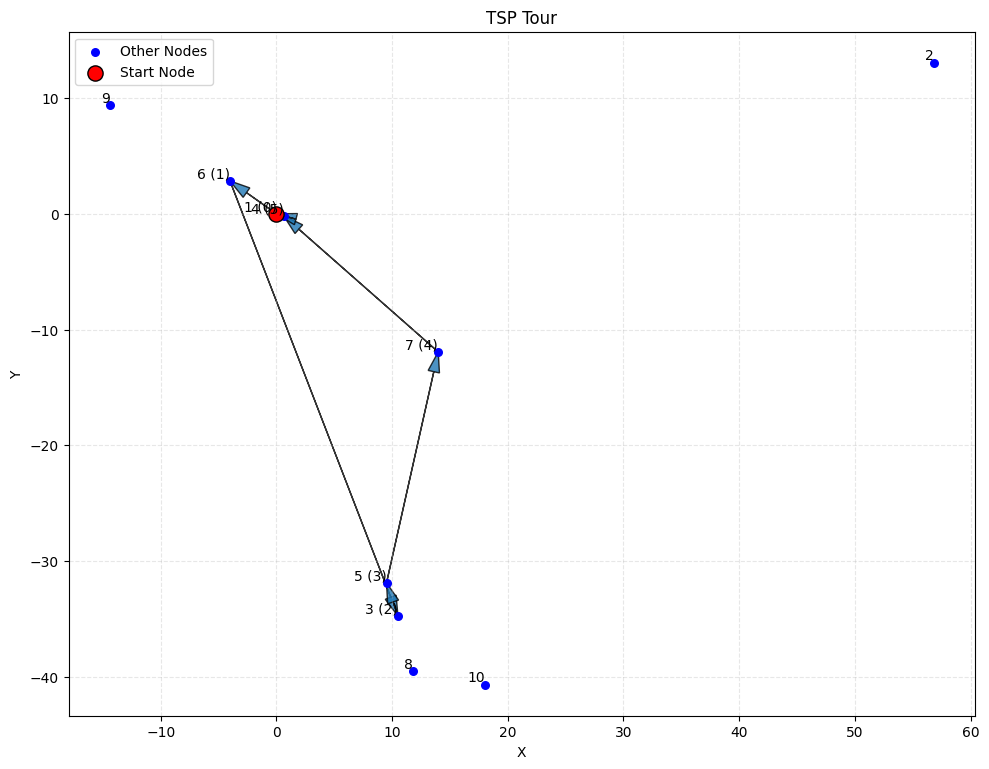


Problem: 
- Lower bound: -.inf
  Upper bound: .inf
  Number of objectives: 1
  Number of constraints: 0
  Number of variables: 189
  Sense: unknown
Solver: 
- Status: ok
  Message: CPLEX 22.1.2\x3a optimal solution; objective 84; 268 simplex iterations
  Termination condition: optimal
  Id: 0
Solution: 
- number of solutions: 0
  number of solutions displayed: 0



In [37]:
# Launch three options (CPLEX)
print(solve_flow_based_problem(model, opt="cplex"))
# print(solve_MTZ_problem(model, opt="cplex"))
# print(solve_hybrid_problem(model, opt="cplex"))


In [25]:
# Launch three options (Gurobi (not working right now))
# print(solve_flow_based_problem(model, opt="gurobi"))
# print(solve_MTZ_problem(model, opt="gurobi"))
# print(solve_hybrid_problem(model, opt="gurobi"))
